# Data Analysis

## House Keeping

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats 
from scipy.stats import shapiro , kstest, mannwhitneyu, ttest_rel
import torch
from torch import nn

In [2]:
# Helper Functions
def clean_df(df, fused=False):
    df = df.drop(columns = [df.columns[0]])
    df.columns = ['name', 'dice_NCR', 'dice_ED', 'dice_ET', 'hausdorff_NCR', 'hausdorff_ED', 'hausdorff_ET']
    df = df.dropna()
    df = df.reset_index(drop=True)
    if fused:
        return df
    df_t2f = df.iloc[::4, :].reset_index(drop=True)
    df_t1n = df.iloc[1::4, :].reset_index(drop=True)
    df_t1c = df.iloc[2::4, :].reset_index(drop=True)
    df_t2w = df.iloc[3::4, :].reset_index(drop=True)
    return df_t2f, df_t1n, df_t1c, df_t2w

In [3]:
def plot_boxplots(A, B):
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    # Dice Scores
    ax[0, 0].boxplot(A[A.columns[1:4]].values)
    ax[0, 0].set_title("SAM2 - Dice")
    ax[0, 0].set_xticklabels(A.columns[1:4], rotation=45)
    ax[0, 0].set_ylim(0, 1)
    ax[0, 0].set_ylabel("Dice Score")

    ax[0, 1].boxplot(B[B.columns[1:4]].values)
    ax[0, 1].set_title("MedSAM2 - Dice")
    ax[0, 1].set_xticklabels(B.columns[1:4], rotation=45)
    ax[0, 1].set_ylim(0, 1)
    ax[0, 1].set_ylabel("Dice Score")

    # Hausdorff 95
    ax[1, 0].boxplot(A[A.columns[4:]].values)
    ax[1, 0].set_title("SAM2 - Hausdorff95")
    ax[1, 0].set_xticklabels(A.columns[4:], rotation=45)
    ax[1, 0].set_ylabel("Hausdorff95")
    ax[1, 0].set_ylim(0, 200) 

    ax[1, 1].boxplot(B[B.columns[4:]].values)
    ax[1, 1].set_title("MedSAM2 - Hausdorff95")
    ax[1, 1].set_xticklabels(B.columns[4:], rotation=45)
    ax[1, 1].set_ylabel("Hausdorff95")
    ax[1, 1].set_ylim(0, 200)  

    plt.tight_layout()
    plt.show()

In [4]:
def bootstrap_ttests(A, B, num_samples=10000, alpha=0.05):
    A = pd.Series(A)
    B = pd.Series(B)


    observed_diff = B.mean() - A.mean()
    print(f"Observed difference of means: {observed_diff:.4f}")

    # Combine and center under null
    combined_mean = (A.mean() + B.mean()) / 2
    A_centered = A - A.mean() + combined_mean
    B_centered = B - B.mean() + combined_mean

    # Bootstrap
    diffs = []
    for _ in range(num_samples):
        sample_A = A_centered.sample(n=len(A), replace=True)
        sample_B = B_centered.sample(n=len(B), replace=True)
        diffs.append(sample_B.mean() - sample_A.mean())

    diffs = np.array(diffs)
    pvalue = np.mean(np.abs(diffs) >= np.abs(observed_diff))
    print(f"Bootstrap p-value (null-centered): {pvalue:.4f}")

    if pvalue < alpha:
        print("Reject H0: mean values differ significantly.")
    else:
        print("Fail to reject H0: no significant difference in mean values.")

In [5]:
def apply_test(A, B, tests):
    NCR_results_dice = tests(A['dice_NCR'], B['dice_NCR'])
    ET_results_dice = tests(A['dice_ET'], B['dice_ET'])
    ED_results_dice = tests(A['dice_ED'], B['dice_ED'])
    
    NCR_results_HD = tests(A['hausdorff_NCR'], B['hausdorff_NCR'])
    ET_results_HD = tests(A['hausdorff_ET'], B['hausdorff_ET'])
    ED_results_HD = tests(A['hausdorff_ED'], B['hausdorff_ED'])
    return f'''
    Results for NCR dice {NCR_results_dice}
    Results for ET dice {ET_results_dice}
    Results for ED dice {ED_results_dice}

    Results for NCR HD {NCR_results_HD}
    Results for ET HD {ET_results_HD}
    Results for ED HD {ED_results_HD} 
                '''

In [6]:
def apply_test(A, B, tests):
    NCR_results_dice = tests(A['dice_NCR'], B['dice_NCR'])
    ET_results_dice = tests(A['dice_ET'], B['dice_ET'])
    ED_results_dice = tests(A['dice_ED'], B['dice_ED'])
    
    NCR_results_HD = tests(A['hausdorff_NCR'], B['hausdorff_NCR'])
    ET_results_HD = tests(A['hausdorff_ET'], B['hausdorff_ET'])
    ED_results_HD = tests(A['hausdorff_ED'], B['hausdorff_ED'])
    return f'''
    Results for NCR dice {NCR_results_dice}
    Results for ET dice {ET_results_dice}
    Results for ED dice {ED_results_dice}

    Results for NCR HD {NCR_results_HD}
    Results for ET HD {ET_results_HD}
    Results for ED HD {ED_results_HD} 
                '''

## Main

### Load Data

In [7]:
SSA_path = '/scratch-second/radjoe_data/true_res/BraTS_SSA/SAM/SAM2/SSA_SAM2.csv'
GLI_path = '/scratch-second/radjoe_data/true_res/BraTS_GLI/SAM/SAM2/SSA_SAM2.csv'

Med_SSA_path = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/BraTS_SSA/MedSAM2/SSA_SAM2.csv'
Med_GLI_path = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/BraTS_GLI/MedSAM2/SSA_SAM2.csv'

In [8]:
point_SSA_MedSAM_path = '/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/results/BraTS_SSA/MedSAM2/SSA_SAM2.csv'

In [9]:
SSA_df = pd.read_csv(SSA_path)
GLI_df = pd.read_csv(GLI_path)

In [10]:
Med_SSA_df = pd.read_csv(Med_SSA_path)
Med_GLI_df = pd.read_csv(Med_GLI_path)

In [11]:
Med_SSA_points = pd.read_csv(point_SSA_MedSAM_path)

In [12]:
Med_SSA_df= clean_df(Med_SSA_df, True)
SSA_df = clean_df(SSA_df, True)
Med_GLI_df = clean_df(Med_GLI_df, True)
GLI_df = clean_df(GLI_df, True)

In [13]:
Med_SSA_points = clean_df(Med_SSA_points, True)

### Data Exploration

In [14]:
Med_GLI_df.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,0.447036,0.523368,0.605659,13.037377,15.418681,12.651124
std,0.223803,0.199038,0.185481,10.797862,11.249565,11.112293
min,0.000000,0.014662,0.001332,1.414214,2.828427,1.414214
25%,0.286000,0.394471,0.494067,7.000000,8.485281,6.862549
50%,0.452865,0.551944,0.634049,10.049875,11.524878,9.219544
75%,0.612021,0.671028,0.746668,14.899665,17.691738,13.190906
max,0.938284,0.942441,0.951499,145.708588,84.972343,108.161919


In [15]:
GLI_df.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET
count,1136.000000,1136.000000,1136.000000,1136.000000,1136.000000,1136.000000
mean,0.385365,0.347512,0.524873,55.539673,51.746486,53.664530
std,0.231743,0.182403,0.220901,29.142783,19.439341,27.292848
min,0.000000,0.001275,0.000000,1.000000,6.633250,2.000000
25%,0.192253,0.205903,0.362270,34.153777,39.140766,36.576632
50%,0.386727,0.349090,0.568745,59.905334,50.385754,56.133766
75%,0.560882,0.478781,0.697475,76.482103,63.635090,73.269609
max,0.934250,0.891049,0.958771,129.916122,106.783897,123.816597


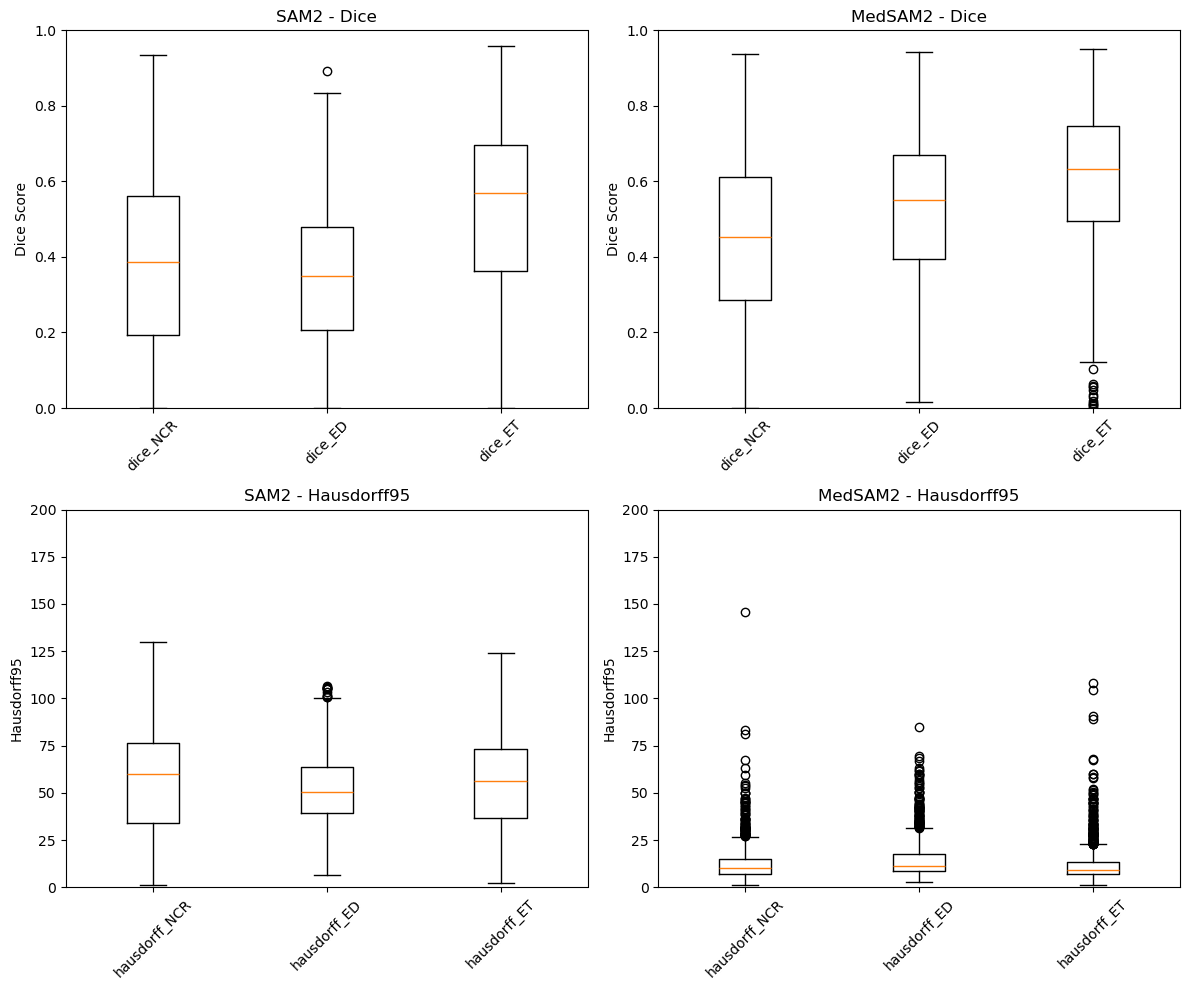

In [16]:
plot_boxplots(GLI_df, Med_GLI_df)

In [17]:
SSA_df.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,0.375947,0.392786,0.490822,56.963956,47.553503,51.353523
std,0.245232,0.173004,0.188613,28.514842,17.799128,23.351031
min,0.000000,0.044684,0.090633,4.123106,12.206555,5.099020
25%,0.176550,0.273714,0.363220,37.357713,32.183034,39.452303
50%,0.359232,0.419771,0.464154,59.464270,47.469442,52.451580
75%,0.575728,0.526939,0.639075,78.790718,61.051275,62.296151
max,0.806059,0.680734,0.870744,116.797249,84.917610,99.420319


In [18]:
Med_SSA_df.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,0.438602,0.545109,0.557221,16.716541,21.846166,15.657536
std,0.260356,0.202449,0.180636,11.152687,14.435496,11.517164
min,0.000243,0.078877,0.141761,3.741657,4.898980,2.236068
25%,0.215850,0.397250,0.455686,10.040524,11.134459,7.511352
50%,0.443903,0.553124,0.572182,13.090773,15.664139,12.569239
75%,0.635091,0.725847,0.683051,21.797055,31.475708,20.328526
max,0.898071,0.892904,0.900694,72.612671,66.468040,66.425903


In [19]:
Med_SSA_points.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,0.438602,0.545109,0.557221,16.716541,21.846166,15.657536
std,0.260356,0.202449,0.180636,11.152687,14.435496,11.517164
min,0.000243,0.078877,0.141761,3.741657,4.898980,2.236068
25%,0.215850,0.397250,0.455686,10.040524,11.134459,7.511352
50%,0.443903,0.553124,0.572182,13.090773,15.664139,12.569239
75%,0.635091,0.725847,0.683051,21.797055,31.475708,20.328526
max,0.898071,0.892904,0.900694,72.612671,66.468040,66.425903


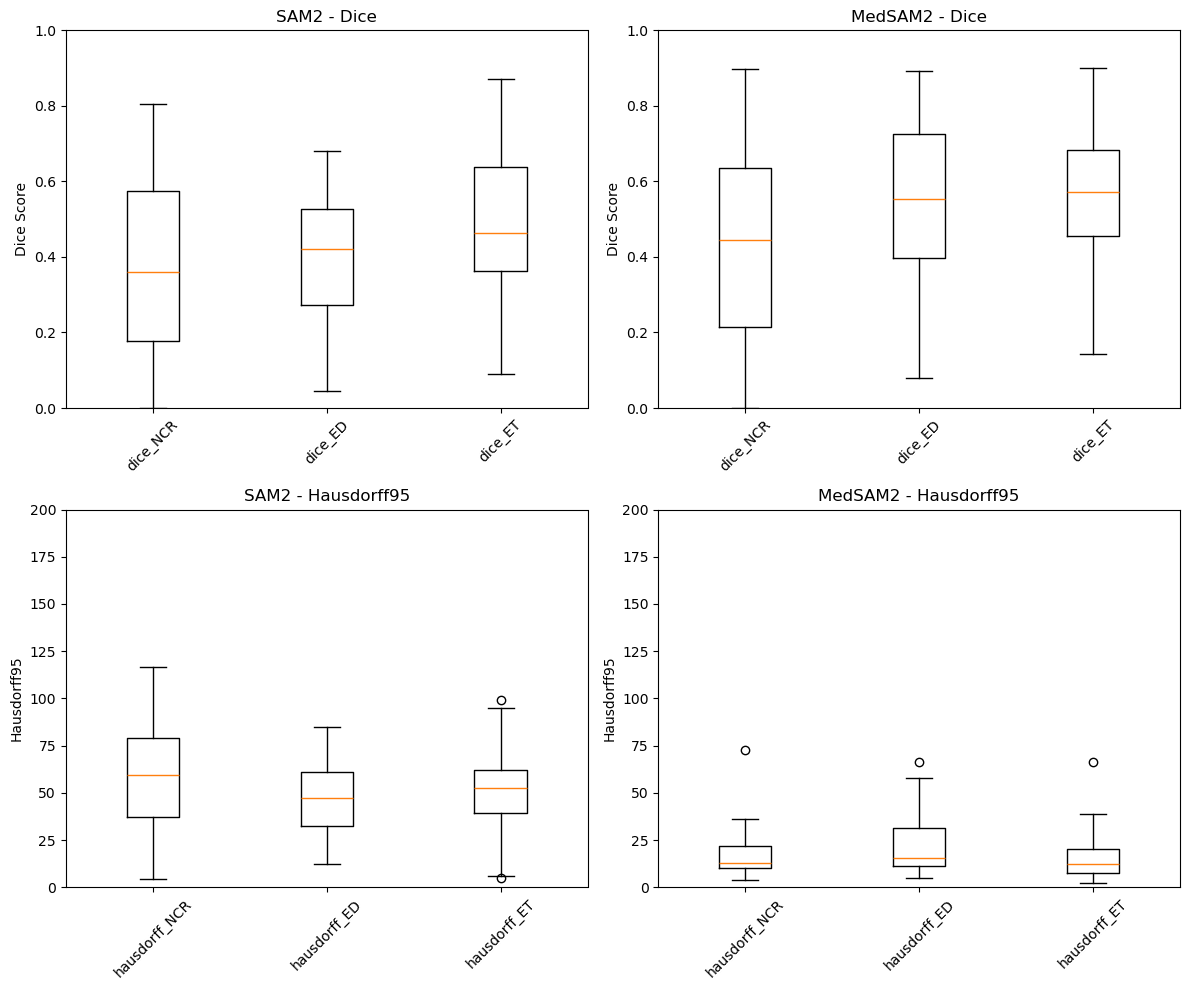

In [20]:
plot_boxplots(SSA_df, Med_SSA_df)

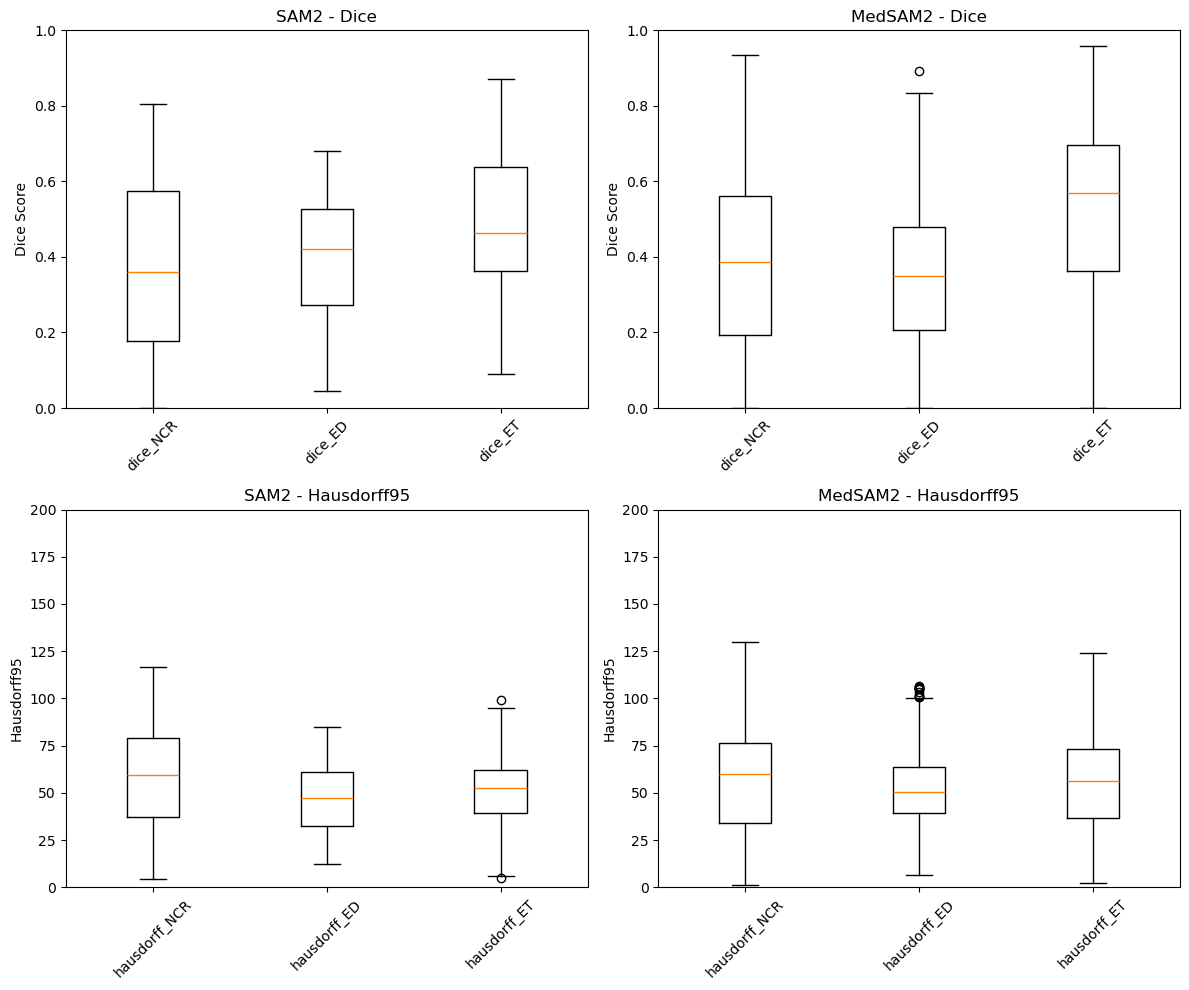

In [21]:
plot_boxplots(SSA_df, GLI_df)

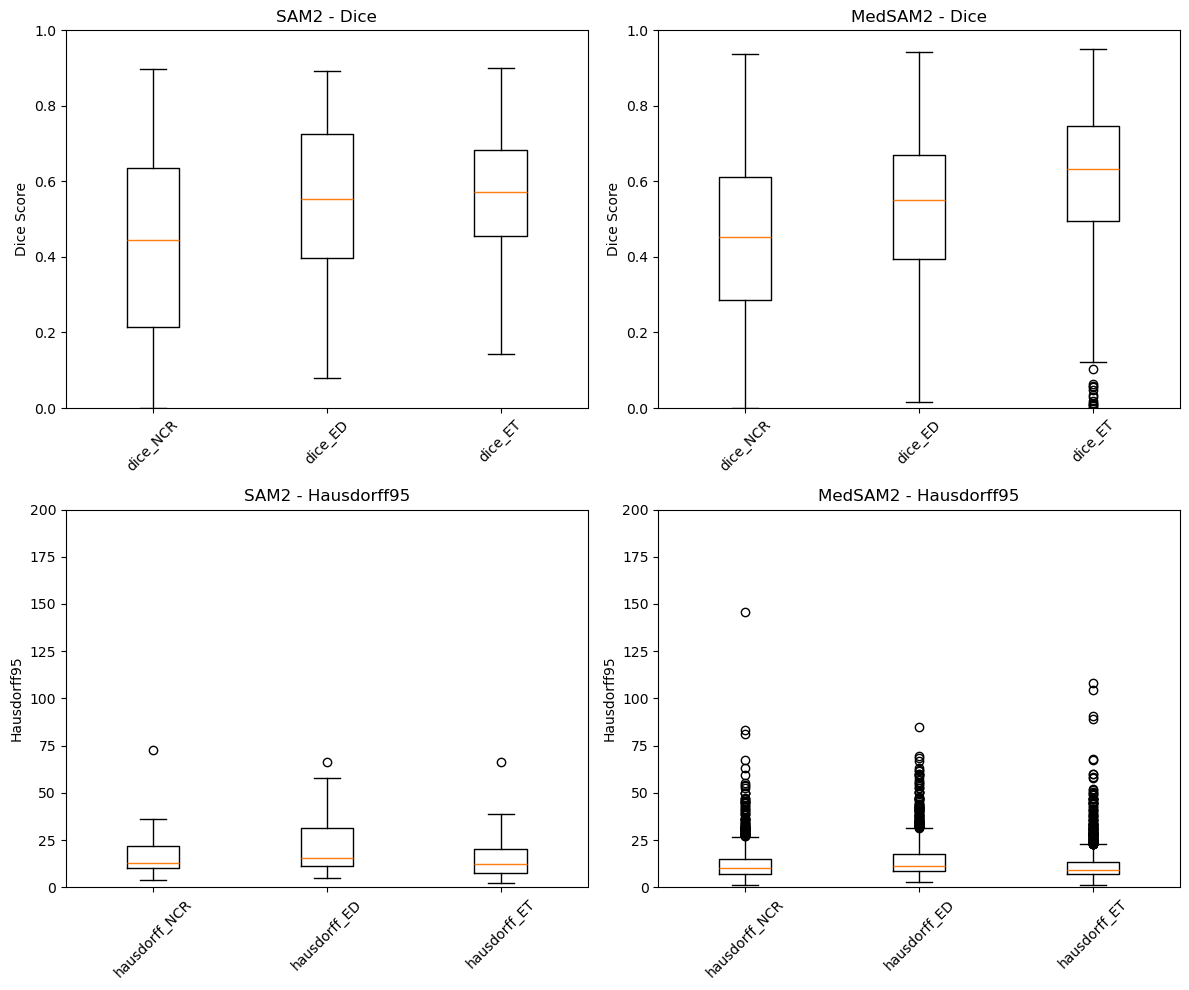

In [22]:
plot_boxplots(Med_SSA_df, Med_GLI_df)

### Significance Test for MedSAM2 vs SAM2 on the same datasets

In [23]:
apply_test(Med_GLI_df, GLI_df, mannwhitneyu)

'\n    Results for NCR dice MannwhitneyuResult(statistic=622882.0, pvalue=1.2098344869421365e-09)\n    Results for ET dice MannwhitneyuResult(statistic=651064.0, pvalue=4.085413113685673e-16)\n    Results for ED dice MannwhitneyuResult(statistic=803448.0, pvalue=1.1888368645562099e-82)\n\n    Results for NCR HD MannwhitneyuResult(statistic=128102.0, pvalue=3.2921455143102457e-198)\n    Results for ET HD MannwhitneyuResult(statistic=118157.0, pvalue=8.371032904158297e-208)\n    Results for ED HD MannwhitneyuResult(statistic=58337.5, pvalue=2.4669723191514594e-270) \n                '

In [24]:
apply_test(Med_SSA_df, SSA_df, mannwhitneyu)

'\n    Results for NCR dice MannwhitneyuResult(statistic=1660.0, pvalue=0.215675875339849)\n    Results for ET dice MannwhitneyuResult(statistic=1779.0, pvalue=0.04891877235770139)\n    Results for ED dice MannwhitneyuResult(statistic=2077.0, pvalue=0.00014449327625974307)\n\n    Results for NCR HD MannwhitneyuResult(statistic=346.0, pvalue=8.516248333051652e-12)\n    Results for ET HD MannwhitneyuResult(statistic=303.5, pvalue=1.3326766352593642e-12)\n    Results for ED HD MannwhitneyuResult(statistic=383.0, pvalue=4.0495811776899406e-11) \n                '

MedSAM2 performs significanlty better and SAM2

In [25]:
apply_test(SSA_df, GLI_df, mannwhitneyu)

'\n    Results for NCR dice MannwhitneyuResult(statistic=30020.5, pvalue=0.791908091832264)\n    Results for ET dice MannwhitneyuResult(statistic=26861.0, pvalue=0.1225165411993924)\n    Results for ED dice MannwhitneyuResult(statistic=35389.0, pvalue=0.05594361561724541)\n\n    Results for NCR HD MannwhitneyuResult(statistic=31414.0, pvalue=0.7637876183877709)\n    Results for ET HD MannwhitneyuResult(statistic=28142.5, pvalue=0.30539234598417675)\n    Results for ED HD MannwhitneyuResult(statistic=27007.0, pvalue=0.1375102684925554) \n                '

In [26]:
apply_test(Med_SSA_df, Med_GLI_df, mannwhitneyu)

'\n    Results for NCR dice MannwhitneyuResult(statistic=25225.0, pvalue=0.8377294479704487)\n    Results for ET dice MannwhitneyuResult(statistic=21339.0, pvalue=0.03756366551378299)\n    Results for ED dice MannwhitneyuResult(statistic=27103.0, pvalue=0.48345708842050283)\n\n    Results for NCR HD MannwhitneyuResult(statistic=33194.5, pvalue=0.0002730132328911427)\n    Results for ET HD MannwhitneyuResult(statistic=31126.0, pvalue=0.008248842216607292)\n    Results for ED HD MannwhitneyuResult(statistic=33495.0, pvalue=0.00015394618608001188) \n                '

### Summary

In [27]:
SSA_sum = pd.DataFrame()
for i in list_SSA:
    temp = pd.DataFrame(i.describe())
    SSA_sum = pd.concat([SSA_sum, temp], axis=1)

NameError: name 'list_SSA' is not defined

In [ ]:
SSA_sum

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,...,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,...,52.000000,52.000000,52.000000,52.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.309616,0.350685,0.386090,63.999215,50.216622,58.597731,0.274699,0.379591,0.319574,62.467290,...,0.460326,13.339778,16.801647,15.508792,0.446480,0.434375,0.504124,48.755813,42.510082,45.131739
std,0.222421,0.146105,0.178113,24.036845,15.494067,21.292504,0.231037,0.124671,0.156044,21.140353,...,0.194735,12.686500,11.866856,10.927809,0.242916,0.165889,0.160419,25.571355,17.694934,25.236286
min,0.000343,0.103974,0.087095,8.185352,23.790754,5.099020,0.000632,0.127629,0.021757,7.095692,...,0.016651,2.449490,4.472136,3.000000,0.000000,0.128741,0.083100,2.982842,14.345709,4.000000
25%,0.128956,0.202356,0.229873,48.027843,39.965527,49.402134,0.062406,0.284167,0.187636,49.371231,...,0.358578,5.889627,8.154578,8.228030,0.264227,0.320341,0.386643,30.479465,28.974085,30.617860
50%,0.302131,0.352243,0.393197,63.104120,49.904219,57.987679,0.231467,0.396526,0.313333,57.616079,...,0.499509,9.847680,11.311549,10.246951,0.499833,0.439779,0.532317,49.592624,40.193224,48.752618
75%,0.480751,0.454053,0.499590,82.832813,58.244808,68.431389,0.415707,0.454708,0.438523,74.742359,...,0.621610,16.186983,21.916663,19.764296,0.634121,0.539515,0.621127,67.868335,52.696694,59.201618
max,0.832919,0.640354,0.801627,112.062263,84.249626,105.801704,0.783559,0.628924,0.643191,107.143364,...,0.805223,83.246020,47.666523,47.968740,0.912569,0.808709,0.756710,111.345856,82.134030,103.662920


In [ ]:
for j in SSA_t1c.columns[1::]:
    # print(j)
    globals()[f'SSA_{j}'] = pd.DataFrame()
    for i in list_SSA:
        temp = pd.DataFrame(i[j].describe())
        globals()[f'SSA_{j}'] = pd.concat([globals()[f'SSA_{j}'], temp], axis=1)
    globals()[f'SSA_{j}'].columns = ['SSA_t2f', 'SSA_t1n', 'SSA_t1c', 'SSA_t2w', 'Med_SSA_t2f', 'Med_SSA_t1n', 'Med_SSA_t1c', 'Med_SSA_t2w', 'Med_SSA_df_fused', 'SSA_df_fused']

In [ ]:
for j in SSA_t1c.columns[1::]:
    # print(j)
    globals()[f'GLI_{j}'] = pd.DataFrame()
    for i in list_GLI:
        temp = pd.DataFrame(i[j].describe())
        globals()[f'GLI_{j}'] = pd.concat([globals()[f'GLI_{j}'], temp], axis=1)
    globals()[f'GLI_{j}'].columns = ['GLI_t2f', 'GLI_t1n', 'GLI_t1c', 'GLI_t2w', 'Med_GLI_t2f', 'Med_GLI_t1n', 'Med_GLI_t1c', 'Med_GLI_t2w', 'Med_GLI_df_fused', 'GLI_df_fused']

In [ ]:
SSA_dice_ED

,SSA_t2f,SSA_t1n,SSA_t1c,SSA_t2w,Med_SSA_t2f,Med_SSA_t1n,Med_SSA_t1c,Med_SSA_t2w,Med_SSA_df_fused,SSA_df_fused
count,52.000000,52.000000,52.000000,52.000000,53.000000,52.000000,52.000000,52.000000,52.000000,50.000000
mean,0.350685,0.379591,0.371623,0.393645,0.485000,0.524658,0.454047,0.466374,0.532714,0.434375
std,0.146105,0.124671,0.148982,0.163420,0.197660,0.206022,0.207036,0.212667,0.209590,0.165889
min,0.103974,0.127629,0.032593,0.073542,0.094833,0.156730,0.037199,0.113124,0.110773,0.128741
25%,0.202356,0.284167,0.268487,0.281090,0.357220,0.343524,0.297241,0.315637,0.385627,0.320341
50%,0.352243,0.396526,0.390819,0.373876,0.481286,0.534582,0.466359,0.422037,0.534873,0.439779
75%,0.454053,0.454708,0.454967,0.497732,0.677904,0.707721,0.621730,0.623677,0.725251,0.539515
max,0.640354,0.628924,0.662039,0.781788,0.873102,0.904528,0.881693,0.876701,0.893048,0.808709


In [ ]:
SSA_dice_ET

,SSA_t2f,SSA_t1n,SSA_t1c,SSA_t2w,Med_SSA_t2f,Med_SSA_t1n,Med_SSA_t1c,Med_SSA_t2w,Med_SSA_df_fused,SSA_df_fused
count,52.000000,52.000000,52.000000,52.000000,53.000000,52.000000,52.000000,52.000000,52.000000,50.000000
mean,0.386090,0.319574,0.394715,0.415151,0.386957,0.407731,0.425155,0.418942,0.460326,0.504124
std,0.178113,0.156044,0.215474,0.184671,0.202835,0.212851,0.227271,0.202772,0.194735,0.160419
min,0.087095,0.021757,0.015934,0.061102,0.035851,0.024520,0.035987,0.007303,0.016651,0.083100
25%,0.229873,0.187636,0.224512,0.274994,0.206328,0.198524,0.223233,0.220333,0.358578,0.386643
50%,0.393197,0.313333,0.376714,0.415273,0.372245,0.441804,0.421968,0.449738,0.499509,0.532317
75%,0.499590,0.438523,0.571938,0.528003,0.522868,0.564983,0.566479,0.600694,0.621610,0.621127
max,0.801627,0.643191,0.851747,0.917977,0.763444,0.893351,0.916655,0.809396,0.805223,0.756710


In [ ]:
GLI_dice_ED

,GLI_t2f,GLI_t1n,GLI_t1c,GLI_t2w,Med_GLI_t2f,Med_GLI_t1n,Med_GLI_t1c,Med_GLI_t2w,Med_GLI_df_fused,GLI_df_fused
count,47.000000,46.000000,46.000000,46.000000,280.000000,280.000000,279.000000,279.000000,274.000000,43.000000
mean,0.326213,0.374789,0.318046,0.344166,0.527942,0.572420,0.482059,0.443537,0.575576,0.397045
std,0.128496,0.135672,0.143704,0.126597,0.205153,0.204205,0.225608,0.206046,0.194945,0.140582
min,0.095522,0.142141,0.103108,0.147171,0.000000,0.000000,0.000000,0.000000,0.000000,0.171977
25%,0.231066,0.293222,0.208393,0.261520,0.374169,0.434533,0.319016,0.289194,0.444318,0.300985
50%,0.309923,0.352121,0.280737,0.313380,0.525323,0.593390,0.494529,0.434517,0.602006,0.378884
75%,0.406307,0.476396,0.411772,0.423147,0.704996,0.728964,0.665286,0.616433,0.720334,0.490793
max,0.592942,0.658357,0.705423,0.683779,0.905932,0.924031,0.917601,0.884835,0.891845,0.701799


In [ ]:
GLI_dice_ET

,GLI_t2f,GLI_t1n,GLI_t1c,GLI_t2w,Med_GLI_t2f,Med_GLI_t1n,Med_GLI_t1c,Med_GLI_t2w,Med_GLI_df_fused,GLI_df_fused
count,47.000000,46.000000,46.000000,46.000000,280.000000,280.000000,279.000000,279.000000,274.000000,43.000000
mean,0.366029,0.332604,0.438390,0.286044,0.406186,0.438147,0.423682,0.431458,0.507833,0.458654
std,0.215925,0.167062,0.279858,0.152538,0.190438,0.207494,0.274596,0.241001,0.207175,0.204014
min,0.001471,0.001331,0.000000,0.000333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000833
25%,0.191344,0.196239,0.195157,0.186203,0.270731,0.318596,0.191560,0.244522,0.390401,0.321806
50%,0.360567,0.356344,0.406822,0.258827,0.403819,0.446081,0.424184,0.422230,0.539340,0.477682
75%,0.535028,0.458423,0.693908,0.392813,0.534420,0.580495,0.623013,0.595486,0.648652,0.594421
max,0.833835,0.697144,0.906390,0.616633,0.912004,0.936501,0.965417,0.959926,0.905139,0.818307


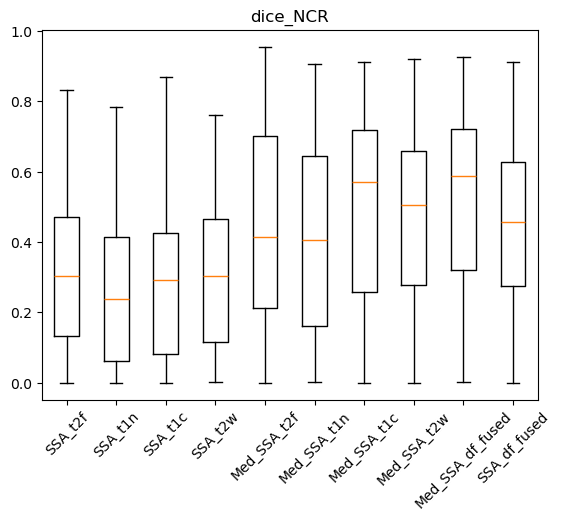

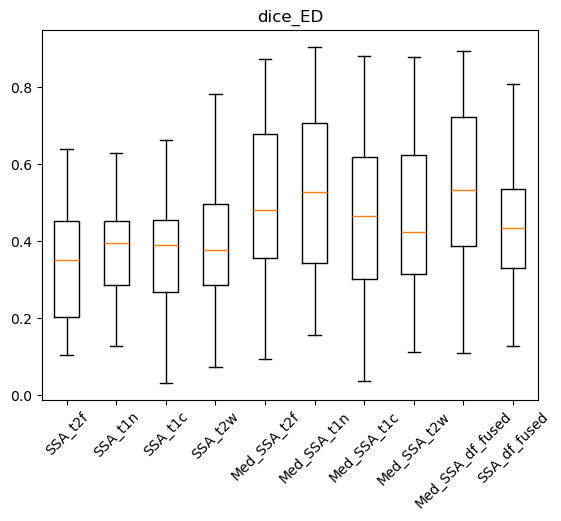

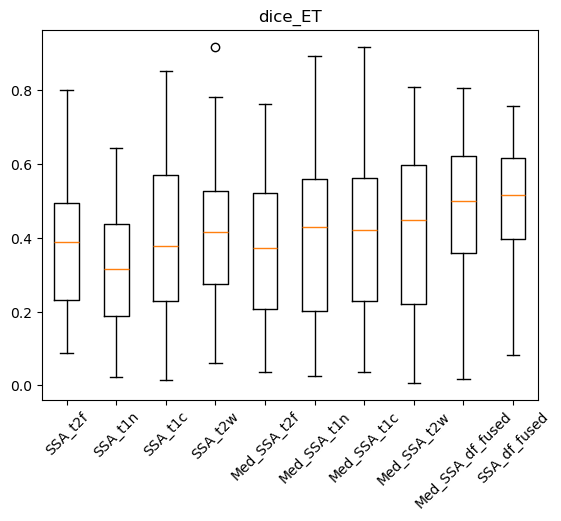

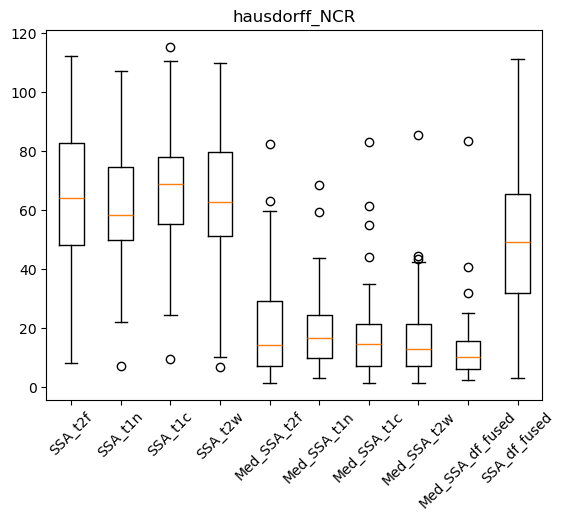

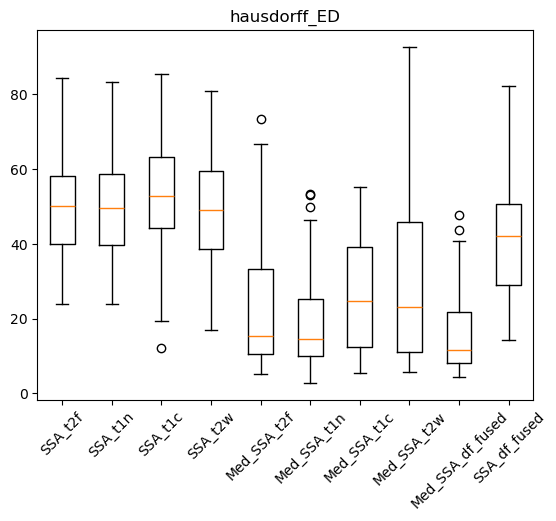

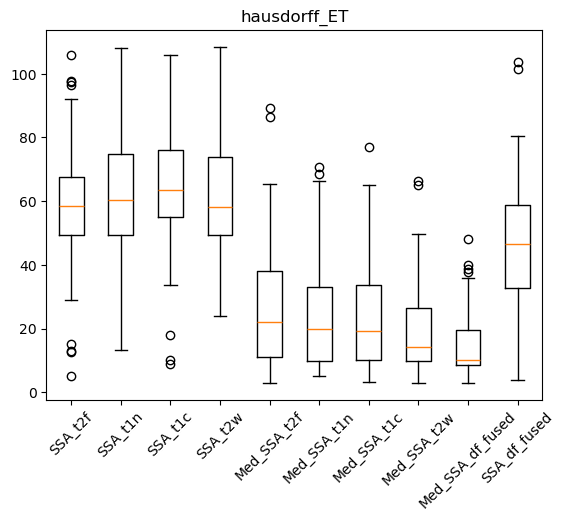

In [ ]:

for j in SSA_t1c.columns[1::]:
    # print(j)
    df = pd.DataFrame()
    for i in list_SSA:
        temp = pd.DataFrame(i[j])
        df = pd.concat([df, temp], axis=1)
    df.columns = ['SSA_t2f', 'SSA_t1n', 'SSA_t1c', 'SSA_t2w', 'Med_SSA_t2f', 'Med_SSA_t1n', 'Med_SSA_t1c', 'Med_SSA_t2w', 'Med_SSA_df_fused', 'SSA_df_fused']
    df = df.fillna(df.mean())
    # print(df)
    ax = plt.boxplot(df.values)
    plt.xticks(range(1,11),df.columns, rotation=45)
    plt.title(j)
    plt.show()
    

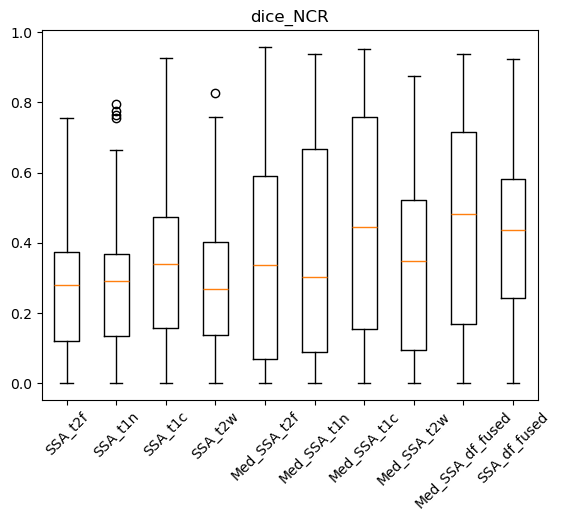

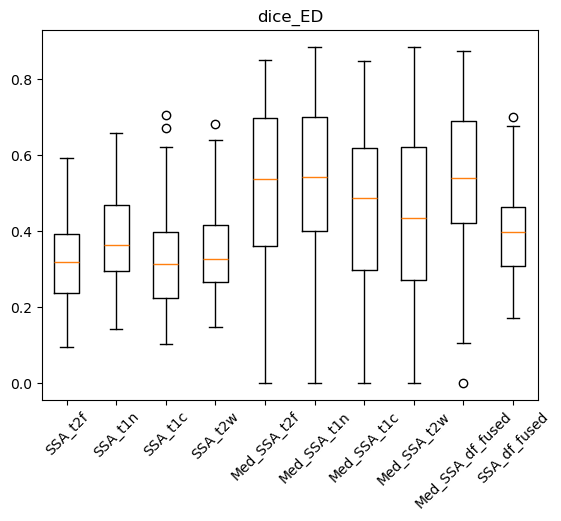

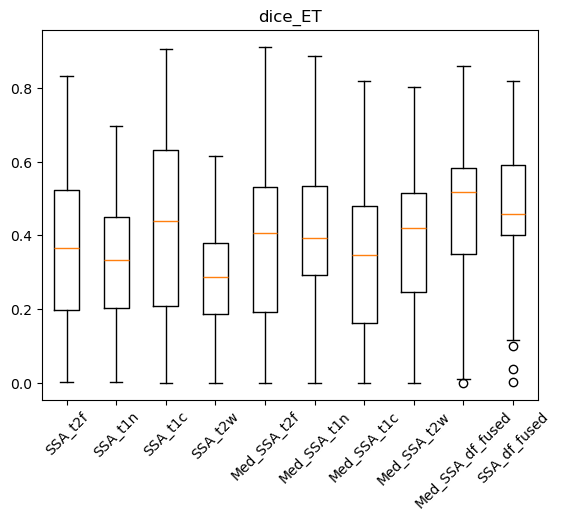

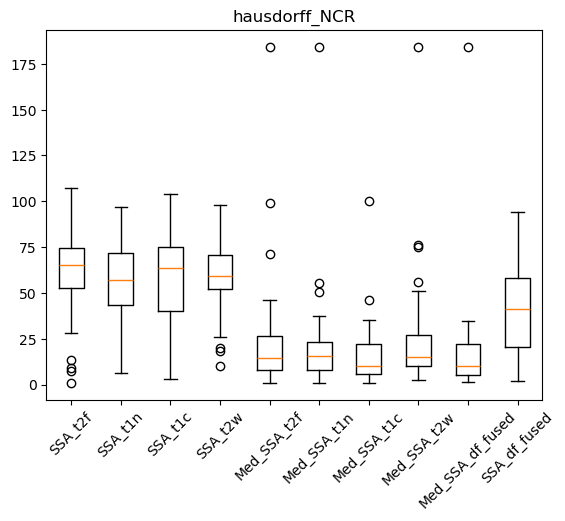

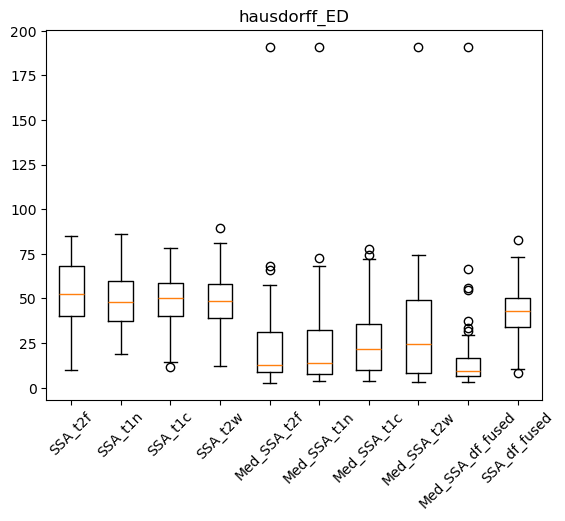

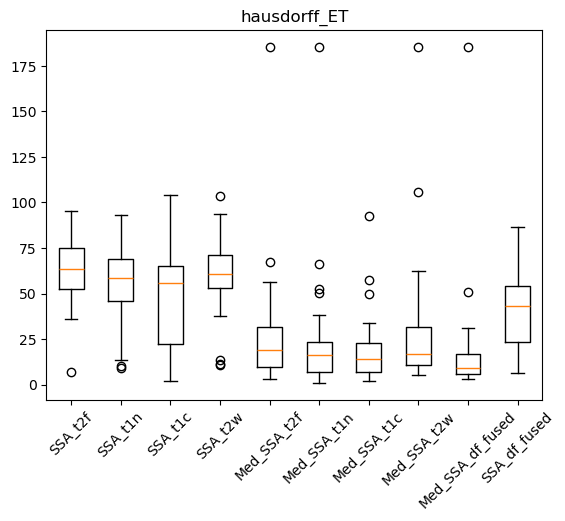

In [ ]:
for j in SSA_t1c.columns[1::]:
    # print(j)
    df = pd.DataFrame()
    for i in list_GLI:
        temp = pd.DataFrame(i[j]).iloc[0:50]
        df = pd.concat([df, temp], axis=1)
    df.columns = ['SSA_t2f', 'SSA_t1n', 'SSA_t1c', 'SSA_t2w', 'Med_SSA_t2f', 'Med_SSA_t1n', 'Med_SSA_t1c', 'Med_SSA_t2w', 'Med_SSA_df_fused', 'SSA_df_fused']
    df = df.fillna(df.mean())
    ax = plt.boxplot(df.values)
    plt.xticks(range(1,11),df.columns, rotation=45)
    plt.title(j)
    plt.show()